# 🌌 Tutorial interativo: AdaptiveClusterIS

Este notebook mostra como o seletor **AdaptiveClusterIS** combina:
- um scorer base (`autoencoder`, `gmm` ou `perplexity`),
- normalização local por vizinhos,
- clustering com MiniBatchKMeans,
- taxas de remoção por cluster baseadas no tamanho do cluster,
- proteção dos pontos mais distantes do centróide dentro de cada cluster.

A ideia é remover instâncias redundantes em regiões densas, preservando exemplos raros ou atípicos.


## 🛠️ Passo 0: Configuração

Escolha os parâmetros principais do método:
- `DATASET_NAME`: `'synthetic'`, `'webkb'`, `'twitter'`, etc.
- `BASE_METHOD`: `'gmm'`, `'autoencoder'` ou `'perplexity'`
- `N_CLUSTERS`: número alvo de clusters usados no passo 2
- `RATE_MIN`, `RATE_MAX`: limites da taxa de remoção por cluster
- `SPARSE_THRESHOLD`: proteção dos pontos mais distantes do centróide
- `LOCAL_NORMALIZATION`: ativa/desativa a normalização local por vizinhos


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
sys.path.append("..")

print("CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ========== CONFIGURAÇÃO ==========
DATASET_NAME = "mpqa"  # 'synthetic', 'webkb', 'twitter', etc.
BASE_METHOD = "perplexity"  # 'gmm', 'autoencoder', 'perplexity'
N_CLUSTERS = 30
RATE_MIN = 0.05
RATE_MAX = 0.6
SPARSE_THRESHOLD = 0.85
LOCAL_NORMALIZATION = True
RANDOM_STATE = 0
# ==================================

plt.style.use("seaborn-v0_8-whitegrid")

print("Dataset :", DATASET_NAME.upper())
print("Scorer  :", BASE_METHOD.upper())
print(f"Clusters: {N_CLUSTERS} | rate_min={RATE_MIN} | rate_max={RATE_MAX}")
print(f"Sparse threshold: {SPARSE_THRESHOLD} | local normalization: {LOCAL_NORMALIZATION}")


CUDA devices: 1
GPU: NVIDIA A100-SXM4-80GB
Dataset : MPQA
Scorer  : PERPLEXITY
Clusters: 30 | rate_min=0.05 | rate_max=0.6
Sparse threshold: 0.85 | local normalization: True


### Carregando o Dataset

- `'synthetic'` — 2D, desbalanceado (85/15%), útil para visualização.
- Datasets reais — carregados a partir de `/data/bernardolemos/datasets/<nome>/tfidf/`.

In [2]:
import numpy as np
from src.main.python.utils.general import get_data

if DATASET_NAME == 'synthetic':
    from sklearn.datasets import make_classification
    X_train, y_train = make_classification(
        n_samples=1200, n_features=2, n_informative=2,
        n_redundant=0, n_clusters_per_class=1,
        weights=[0.85, 0.15], class_sep=1.5,
        flip_y=0.01, random_state=RANDOM_STATE
    )
    np.random.seed(RANDOM_STATE)
    outlier_idx = np.random.choice(len(X_train), size=30, replace=False)
    X_train[outlier_idx] += np.random.uniform(-7, 7, size=(30, 2))
    X_test, y_test = X_train.copy(), y_train.copy()
    print(f'Sintético: {X_train.shape[0]} amostras, {X_train.shape[1]} dims')
    print(f'Classes  : {np.bincount(y_train)}')
else:
    inputdir = f'/data/bernardolemos/datasets/{DATASET_NAME}/jina-v5/'
    X_train, y_train, X_test, y_test, n_classes = get_data(inputdir, f=0)
    print(f"Dataset real '{DATASET_NAME}' carregado:")
    print(f'  X_train: {X_train.shape}')
    print(f'  Classes: {np.bincount(y_train)}')

Dataset real 'mpqa' carregado:
  X_train: (9545, 256)
  Classes: [6564 2981]


In [3]:
def summarize_selection(selector, X, y):
    mask = np.asarray(selector.mask)
    kept = int(mask.sum())
    removed = int(len(y) - kept)
    print("=" * 60)
    print("Resumo da seleção")
    print("=" * 60)
    print(f"Total original : {len(y):>6}")
    print(f"Mantidas       : {kept:>6}  ({100 * kept / len(y):.1f}%)")
    print(f"Removidas      : {removed:>6}  ({100 * removed / len(y):.1f}%)")
    print(f"Reduction      : {selector.reduction_:.3f}")
    print(f"n_clusters     : {len(selector.cluster_sizes_) if hasattr(selector, 'cluster_sizes_') else 'n/a'}")
    print("=" * 60)
    return mask


## 📈 Passo 1: Scoring com AdaptiveClusterIS

O seletor usa o scorer base para gerar scores por instância e, em seguida, aplica:
- `raw_scores_` — score original do método base,
- `scores_` — score já usado para ranking interno após normalização local opcional,
- `local_medians_` — mediana dos vizinhos usados quando `local_normalization=True`.

Depois disso, o método calcula os clusters e define uma taxa de remoção por cluster.


In [5]:
from src.main.python.iSel.adaptive_cluster_is import AdaptiveClusterIS

selector = AdaptiveClusterIS(
    base_method=BASE_METHOD,
    n_clusters=N_CLUSTERS,
    rate_min=RATE_MIN,
    rate_max=RATE_MAX,
    sparse_threshold=SPARSE_THRESHOLD,
    local_normalization=LOCAL_NORMALIZATION,
    random_state=RANDOM_STATE,
)

X_sel, y_sel = selector.select_data(X_train, y_train)

scores = selector.scores_
raw_scores = selector.raw_scores_

print(f"\nScores ({BASE_METHOD.upper()}):")
print(f"  raw min={raw_scores.min():.6f}    raw median={np.median(raw_scores):.6f}    raw max={raw_scores.max():.6f}")
print(f"  used min={scores.min():.6f}    used median={np.median(scores):.6f}    used max={scores.max():.6f}")
print(f"  p25={np.percentile(scores, 25):.6f}   p75={np.percentile(scores, 75):.6f}")

if hasattr(selector, "local_medians_"):
    print(f"  local_median_mean={selector.local_medians_.mean():.6f}")


[AdaptiveClusterIS] Step 1 — scoring via 'perplexity' …
[PerplexityIS] Fitting LDA with 30 topics on 9545 instances …


[PerplexityIS] Perplexity stats — min: 1.1974, median: 2.1165, max: 8.9500
[PerplexityIS] Redundancy threshold (p0.0): 1.1974 → 0 candidates
[PerplexityIS] Noise threshold (p100.0): 8.9500 → 0 candidates
[PerplexityIS] Removed 0 redundant + 0 noisy = 0 total instances
[PerplexityIS] Kept 9545 / 9545 (reduction = 0.00%)
[AdaptiveClusterIS] Step 1.5 — Local Normalization (KNN) …
[AdaptiveClusterIS] Step 2 — clustering into 30 groups …
[AdaptiveClusterIS] Cluster sizes: min=67, median=282, max=912
[AdaptiveClusterIS] Removal rates: min=0.156, median=0.325, max=0.470
[AdaptiveClusterIS] Step 3 — applying cluster selection …
[AdaptiveClusterIS] Done — removed 3461 / 9545 (reduction = 36.26%)

Scores (PERPLEXITY):
  raw min=1.197361    raw median=2.116536    raw max=8.949972
  used min=0.135584    used median=1.000010    used max=7.382298
  p25=0.935334   p75=1.107193
  local_median_mean=2.548905


## ✂️ Passo 2: Resultado da seleção

Agora vamos resumir o que o `AdaptiveClusterIS` realmente fez:
- quantas instâncias ficaram,
- quantas foram removidas,
- o quanto isso reduz o conjunto,
- como os clusters foram usados para controlar a remoção.


In [6]:
mask = summarize_selection(selector, X_train, y_train)

print("\nSample indices kept (first 15):")
print(selector.sample_indices_[:15])

print("\nCluster-level summary:")
print(f"  cluster_sizes_ min/median/max = {selector.cluster_sizes_.min():.1f} / {np.median(selector.cluster_sizes_):.1f} / {selector.cluster_sizes_.max():.1f}")
print(f"  removal_rates_ min/median/max = {selector.removal_rates_.min():.3f} / {np.median(selector.removal_rates_):.3f} / {selector.removal_rates_.max():.3f}")
print(f"  mean centroid distance = {selector.centroid_dist_.mean():.6f}")


Resumo da seleção
Total original :   9545
Mantidas       :   6084  (63.7%)
Removidas      :   3461  (36.3%)
Reduction      : 0.363
n_clusters     : 30

Sample indices kept (first 15):
[ 0  1  2  3  5  7  8  9 12 13 14 15 16 18 21]

Cluster-level summary:
  cluster_sizes_ min/median/max = 67.0 / 282.0 / 912.0
  removal_rates_ min/median/max = 0.156 / 0.325 / 0.470
  mean centroid distance = 0.576986


## 🧪 Passo 2.5: Proporção de classes por cluster

Esta checagem ajuda a responder uma pergunta importante: os clusters estão agrupando principalmente exemplos da mesma classe, ou estão misturando várias classes?
Se a maioria dos clusters for relativamente "pura", isso costuma fazer mais sentido para a estratégia de remoção local.


Contagem por cluster e classe:
            Classe 0  Classe 1
Cluster 0        260        23
Cluster 1        517       348
Cluster 2        199        20
Cluster 3        109       287
Cluster 4        127         1
Cluster 5         47       125
Cluster 6        620       292
Cluster 7        141         0
Cluster 8        422       107
Cluster 9         92         4
Cluster 10       214         4
Cluster 11       125        86
Cluster 12       434        41
Cluster 13         7       134
Cluster 14       218         8
Cluster 15        13       200
Cluster 16       323        95
Cluster 17        12        63
Cluster 18       204        17
Cluster 19       441        19
Cluster 20       404        32
Cluster 21       344        47
Cluster 22        52       244
Cluster 23       227        54
Cluster 24       305        39
Cluster 25       385        28
Cluster 26       237        62
Cluster 27        42       452
Cluster 28        23       102
Cluster 29        20        47

Proporç

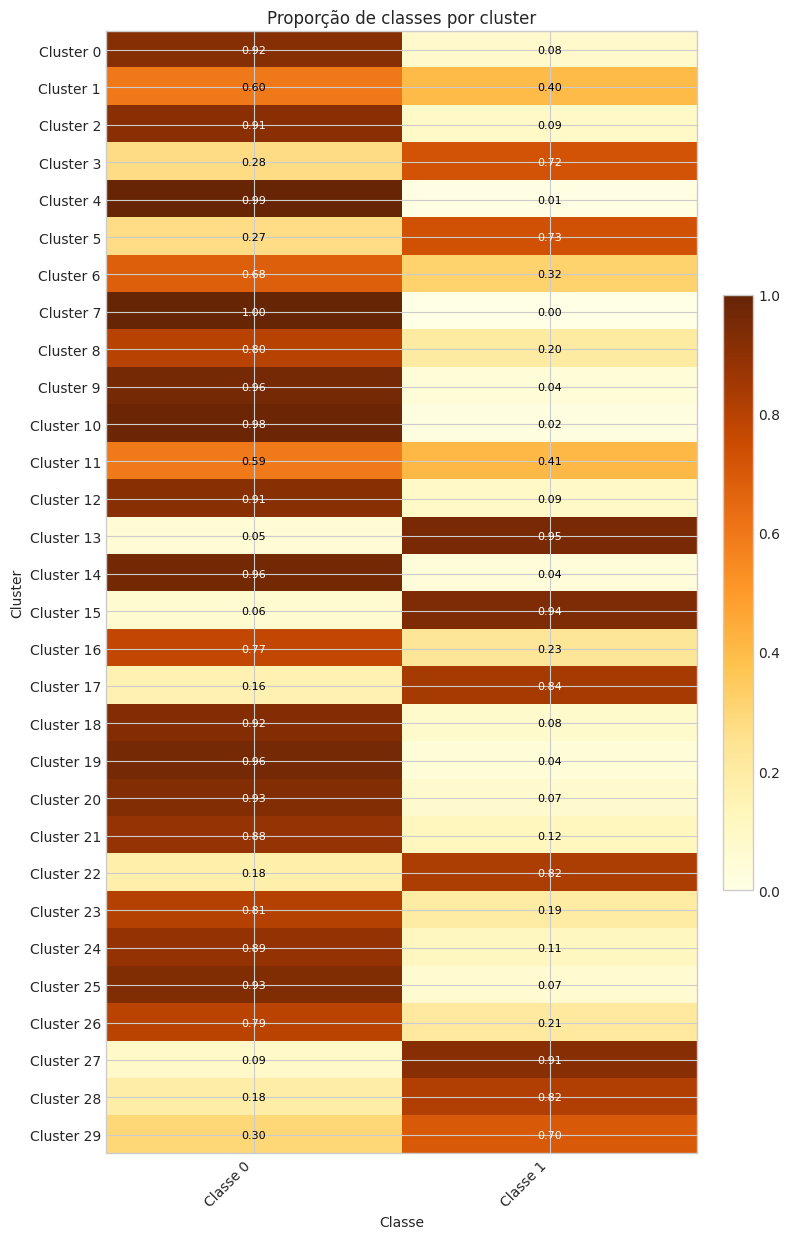

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

labels = selector.labels_
cluster_ids = np.unique(labels)
classes = np.unique(y_train)

# matriz de contagem: linhas = clusters, colunas = classes
cluster_class_counts = pd.DataFrame(
    np.array([
        [(y_train[(labels == c) & (y_train == cls)]).shape[0] for cls in classes]
        for c in cluster_ids
        ]),
    index=[f"Cluster {c}" for c in cluster_ids],
    columns=[f"Classe {cls}" for cls in classes],
)

# proporções dentro de cada cluster
cluster_class_props = cluster_class_counts.div(cluster_class_counts.sum(axis=1), axis=0)

print("Contagem por cluster e classe:")
print(cluster_class_counts.to_string())
print("\nProporção relativa dentro de cada cluster:")
print(cluster_class_props.round(3).to_string())

# heatmap simples
fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(classes) + 2), max(5, 0.35 * len(cluster_ids) + 2)))
img = ax.imshow(cluster_class_props.values, aspect='auto', cmap='YlOrBr')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f"Classe {cls}" for cls in classes], rotation=45, ha='right')
ax.set_yticks(range(len(cluster_ids)))
ax.set_yticklabels([f"Cluster {c}" for c in cluster_ids])
ax.set_xlabel('Classe')
ax.set_ylabel('Cluster')
ax.set_title('Proporção de classes por cluster')

for i in range(cluster_class_props.shape[0]):
    for j in range(cluster_class_props.shape[1]):
        val = cluster_class_props.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=8, color='black' if val < 0.65 else 'white')

plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 📊 Passo 3: Métricas por classe

Aqui analisamos como a seleção afeta cada classe. Como o método tenta preservar regiões raras e atípicas, vale verificar se a distribuição após a seleção ficou mais equilibrada.


 Classe  Total  Mantidas  Removidas  Pct_Classe_Original  Pct_Classe_Apos  Pct_Mantidas  Pct_Removidas
      0   6564      4152       2412                68.77            68.24          63.3           36.7
      1   2981      1932       1049                31.23            31.76          64.8           35.2


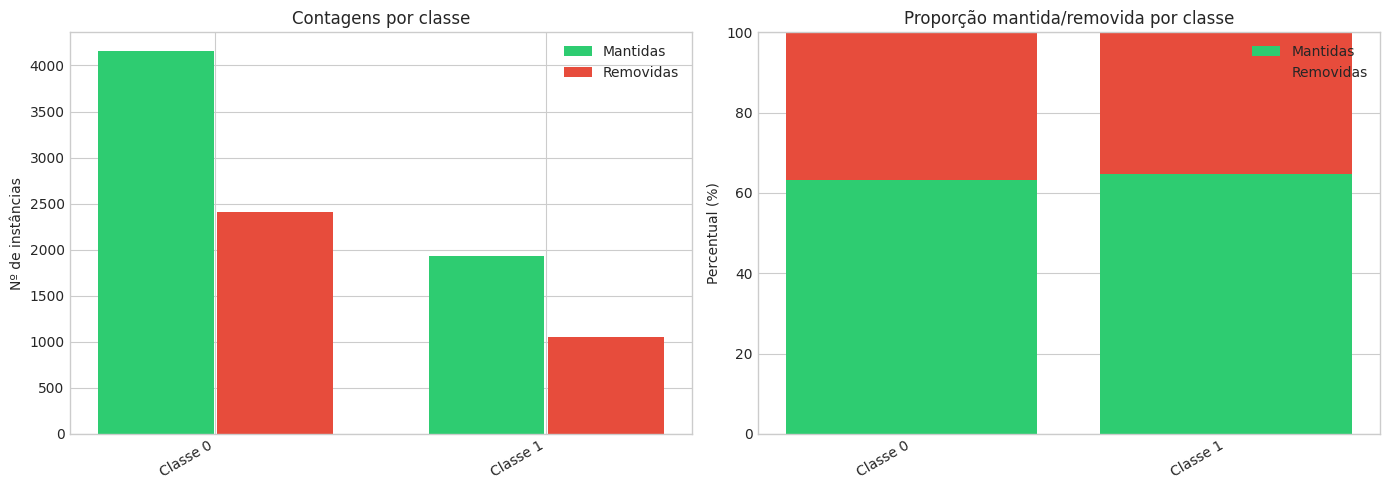

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mask = np.asarray(selector.mask)
classes = np.unique(y_train)
n_total = len(y_train)
n_kept = int(mask.sum())

rows = []
for c in classes:
    idx_c = y_train == c
    total_c = int(idx_c.sum())
    kept_c = int((mask & idx_c).sum())
    removed_c = total_c - kept_c
    pct_class_before = 100 * total_c / n_total
    pct_class_after = (100 * kept_c / n_kept) if n_kept > 0 else 0.0
    pct_kept = 100 * kept_c / total_c if total_c > 0 else 0.0
    pct_removed = 100 * removed_c / total_c if total_c > 0 else 0.0
    rows.append(
        dict(
            Classe=int(c),
            Total=total_c,
            Mantidas=kept_c,
            Removidas=removed_c,
            Pct_Classe_Original=round(pct_class_before, 2),
            Pct_Classe_Apos=round(pct_class_after, 2),
            Pct_Mantidas=round(pct_kept, 1),
            Pct_Removidas=round(pct_removed, 1),
        )
    )

df = pd.DataFrame(rows).sort_values("Total", ascending=False)
print(df.to_string(index=False))

# Gráfico 1: contagens absolutas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
x = np.arange(len(df))
ax.bar(x - 0.18, df["Mantidas"], width=0.35, label="Mantidas", color="#2ecc71")
ax.bar(x + 0.18, df["Removidas"], width=0.35, label="Removidas", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels([f"Classe {c}" for c in df["Classe"]], rotation=30, ha="right")
ax.set_ylabel("Nº de instâncias")
ax.set_title("Contagens por classe")
ax.legend()

# Gráfico 2: proporções percentuais
ax = axes[1]
ax.bar(x, df["Pct_Mantidas"], label="Mantidas", color="#2ecc71")
ax.bar(x, df["Pct_Removidas"], bottom=df["Pct_Mantidas"], label="Removidas", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels([f"Classe {c}" for c in df["Classe"]], rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Percentual (%)")
ax.set_title("Proporção mantida/removida por classe")
ax.legend()

plt.tight_layout()
plt.show()


## 🔬 Passo 4: Análise dos scores e dos clusters

Esta etapa conecta o que foi calculado no seletor com o que o notebook mostra visualmente:
- distribuição dos scores usados para decidir a remoção,
- relação entre tamanho do cluster e taxa de remoção,
- proteção dos pontos mais afastados do centróide.


          metric    value
   raw_score_min 1.197361
raw_score_median 2.116536
   raw_score_max 8.949972
       score_min 0.135584
    score_median 1.000010
       score_max 7.382298


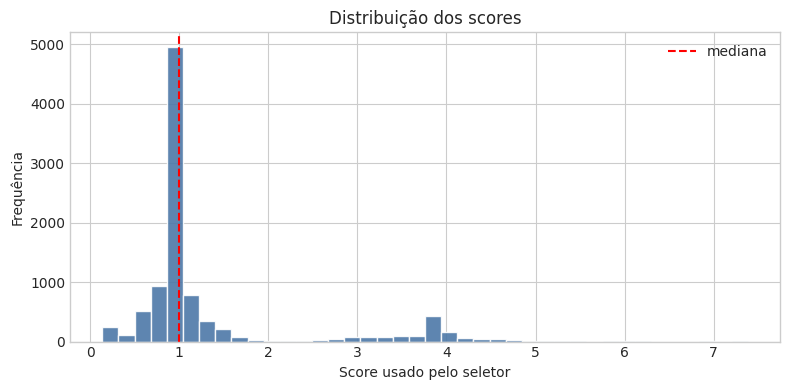

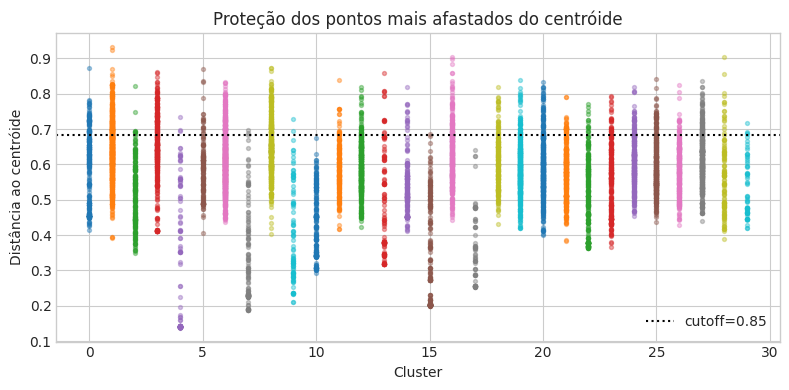

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores = selector.scores_
raw_scores = selector.raw_scores_
labels = selector.labels_
centroid_dist = selector.centroid_dist_

# Estatísticas globais
score_summary = pd.DataFrame(
    {
        "metric": ["raw_score_min", "raw_score_median", "raw_score_max", "score_min", "score_median", "score_max"],
        "value": [
            float(raw_scores.min()),
            float(np.median(raw_scores)),
            float(raw_scores.max()),
            float(scores.min()),
            float(np.median(scores)),
            float(scores.max()),
        ],
    }
)
print(score_summary.to_string(index=False))

# Histograma dos scores usados
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=40, color="#4C78A8", edgecolor="white", alpha=0.9)
plt.axvline(np.median(scores), color="red", linestyle="--", label="mediana")
plt.xlabel("Score usado pelo seletor")
plt.ylabel("Frequência")
plt.title("Distribuição dos scores")
plt.legend()
plt.tight_layout()
plt.show()

# Distribuição da distância ao centróide por cluster
plt.figure(figsize=(8, 4))
for c in range(len(selector.cluster_sizes_)):
    vals = centroid_dist[labels == c]
    if len(vals) > 0:
        plt.scatter([c] * len(vals), vals, s=8, alpha=0.4)
plt.axhline(np.quantile(centroid_dist, SPARSE_THRESHOLD), color="black", linestyle=":", label=f"cutoff={SPARSE_THRESHOLD}")
plt.xlabel("Cluster")
plt.ylabel("Distância ao centróide")
plt.title("Proteção dos pontos mais afastados do centróide")
plt.legend()
plt.tight_layout()
plt.show()


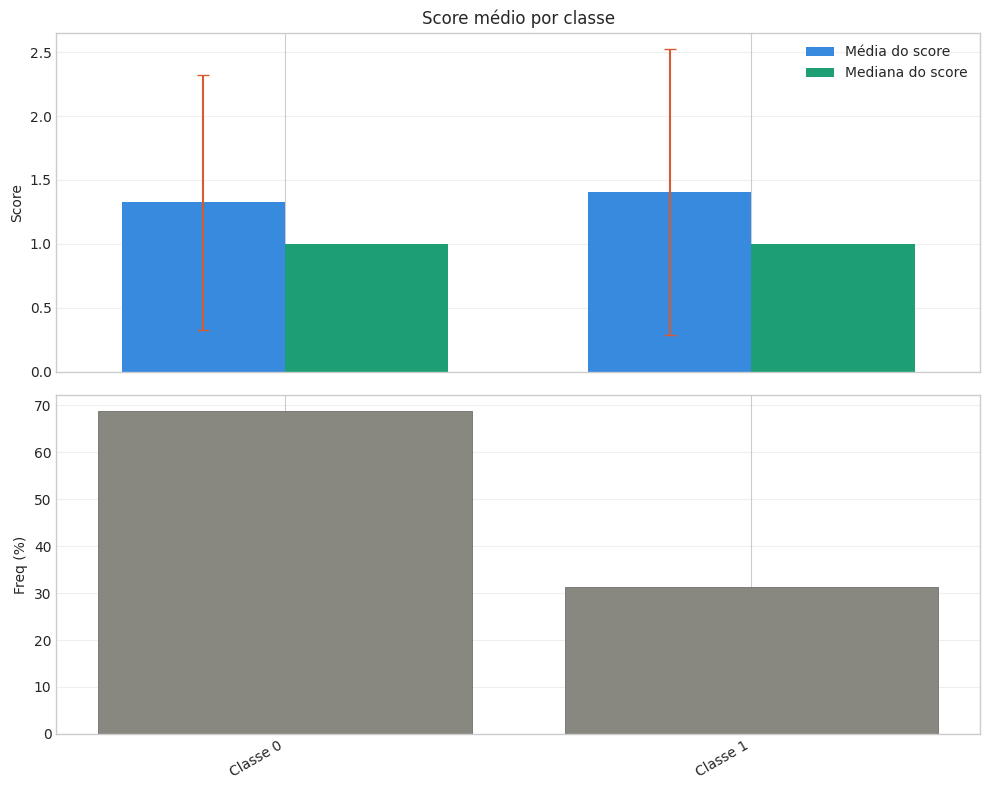

In [10]:
# ── Plot: erro de reconstrução por classe ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

classes_sorted = np.unique(y_train)
x = np.arange(len(classes_sorted))
width = 0.35

# Barras: score médio e mediana por classe
mean_scores = np.array([scores[y_train == c].mean() for c in classes_sorted])
median_scores = np.array([np.median(scores[y_train == c]) for c in classes_sorted])
std_scores = np.array([scores[y_train == c].std() for c in classes_sorted])

ax1.bar(x - width / 2, mean_scores, width, label='Média do score', color='#378ADD')
ax1.bar(x + width / 2, median_scores, width, label='Mediana do score', color='#1D9E75')
ax1.errorbar(x - width / 2, mean_scores, yerr=std_scores, fmt='none', color='#D85A30', capsize=4, linewidth=1.5)
ax1.set_ylabel('Score')
ax1.set_title('Score médio por classe')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Barras: frequência das classes
class_freq = np.array([np.sum(y_train == c) / len(y_train) for c in classes_sorted])
ax2.bar(x, class_freq * 100, color='#888780', edgecolor='#5F5E5A', linewidth=0.5)
ax2.set_ylabel('Freq (%)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Classe {c}' for c in classes_sorted], rotation=30, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



--- AdaptiveClusterIS Statistics ---
Median of scores: 1.000010
Mean of scores: 1.351212
Mask shape: (9545,)
X_train shape: (9545, 256)
Selected fraction: 0.637
Mask shape matches X_train shape!

Top clusters by size:
 cluster  size  removal_rate  mean_score
       6   912      0.470101    1.727080
       1   865      0.464778    1.572309
       8   529      0.408755    1.765472
      27   494      0.400129    1.544801
      12   475      0.395112    1.510728
      19   460      0.390970    1.337692
      20   436      0.383983    1.454803
      16   418      0.378429    0.994206
      25   413      0.376835    0.995737
       3   396      0.371239    1.663959


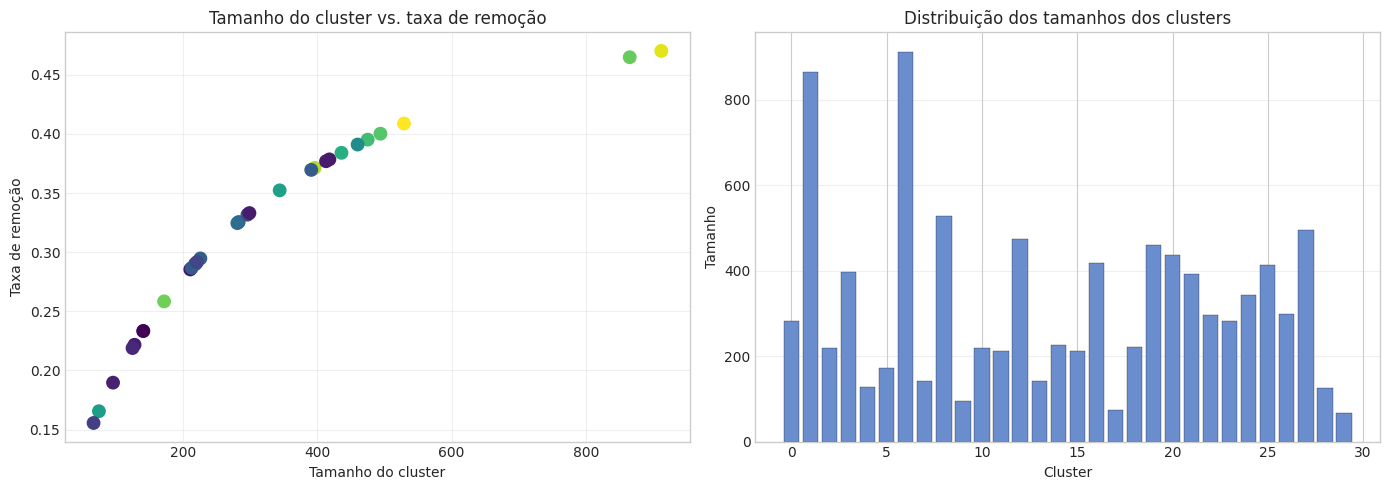

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extração segura das informações do seletor
mask = np.asarray(selector.mask)
scores = selector.scores_
labels = selector.labels_

print("\n--- AdaptiveClusterIS Statistics ---")
print(f"Median of scores: {np.median(scores):.6f}")
print(f"Mean of scores: {np.mean(scores):.6f}")
print(f"Mask shape: {mask.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"Selected fraction: {mask.mean():.3f}")
assert mask.shape[0] == X_train.shape[0]
print("Mask shape matches X_train shape!")

# Tabela resumindo clusters
cluster_df = pd.DataFrame(
    {
        "cluster": np.arange(len(selector.cluster_sizes_)),
        "size": selector.cluster_sizes_.astype(int),
        "removal_rate": selector.removal_rates_,
        "mean_score": np.array([
            float(scores[labels == c].mean()) if np.any(labels == c) else np.nan
            for c in range(len(selector.cluster_sizes_))
        ]),
    }
)
print("\nTop clusters by size:")
print(cluster_df.sort_values("size", ascending=False).head(10).to_string(index=False))

# Visualização final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(cluster_df["size"], cluster_df["removal_rate"], s=80, c=cluster_df["mean_score"], cmap="viridis")
axes[0].set_xlabel("Tamanho do cluster")
axes[0].set_ylabel("Taxa de remoção")
axes[0].set_title("Tamanho do cluster vs. taxa de remoção")
axes[0].grid(True, alpha=0.3)

axes[1].bar(cluster_df["cluster"], cluster_df["size"], color="#6A8DCD", edgecolor="black", linewidth=0.2)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Tamanho")
axes[1].set_title("Distribuição dos tamanhos dos clusters")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Cluster Approach Specifics

`AdaptiveClusterIS` substitui as zonas globais Q1–Q4 por clusters locais gerados com MiniBatchKMeans.

1. **Cluster density via size**: o tamanho de cada cluster funciona como proxy para densidade.
2. **Adaptive removal rates**: clusters maiores recebem maior taxa de remoção; clusters menores são preservados.
3. **In-cluster protection**: instâncias muito distantes do centróide são protegidas do descarte.
4. **Score-based sampling**: dentro do cluster, a probabilidade de remoção é inversamente proporcional ao score.

Os próximos gráficos ajudam a visualizar exatamente como isso aparece no notebook.


Median Cluster Size: 282.0
 Cluster ID  Size  Removal Rate  Mean Centroid Distance
          6   912      0.470101                0.610752
          1   865      0.464778                0.644076
          8   529      0.408755                0.646956
         27   494      0.400129                0.613506
         12   475      0.395112                0.591225
         19   460      0.390970                0.588968
         20   436      0.383983                0.593941
         16   418      0.378429                0.624272
         25   413      0.376835                0.592740
          3   396      0.371239                0.646008
         21   391      0.369539                0.578650
         24   344      0.352236                0.606449


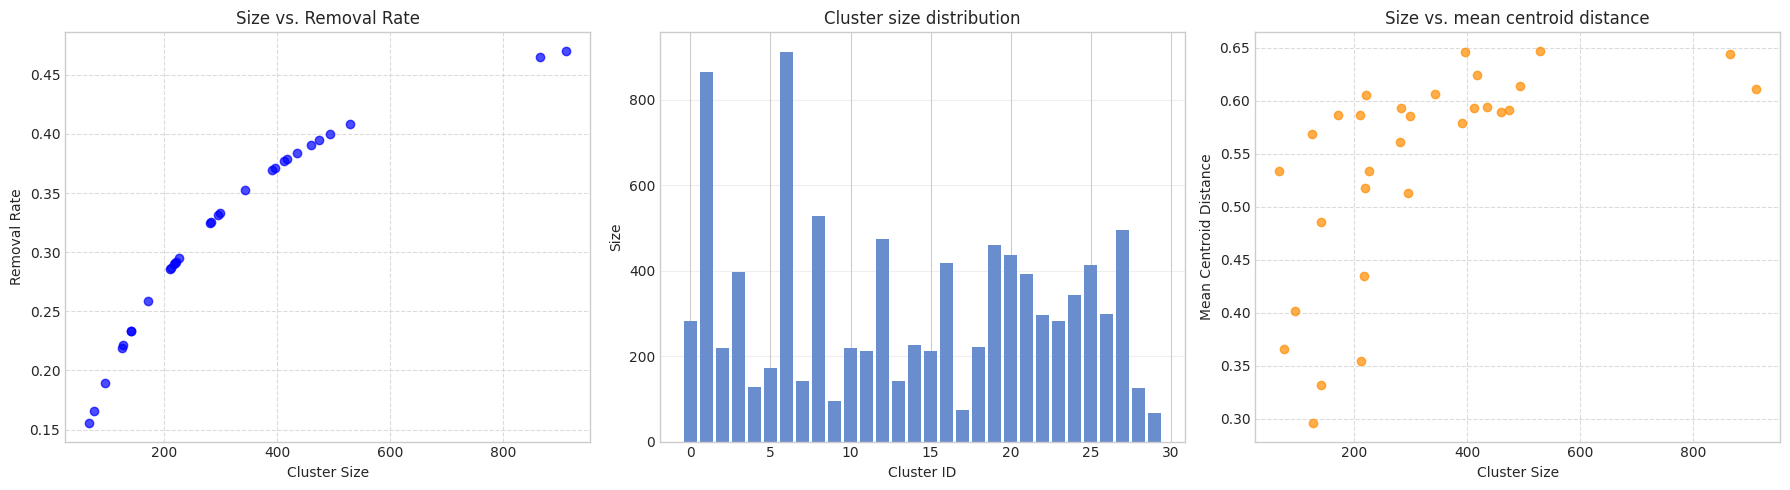

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extrai atributos relevantes do seletor
sizes = selector.cluster_sizes_
rates = selector.removal_rates_
labels = selector.labels_
centroid_dist = selector.centroid_dist_

cluster_df = pd.DataFrame(
    {
        "Cluster ID": np.arange(len(sizes)),
        "Size": sizes.astype(int),
        "Removal Rate": rates,
        "Mean Centroid Distance": np.array([
            float(centroid_dist[labels == i].mean()) if np.any(labels == i) else np.nan
            for i in range(len(sizes))
        ]),
    }
).sort_values("Size", ascending=False).reset_index(drop=True)

print(f"Median Cluster Size: {selector.median_cluster_size_}")
print(cluster_df.head(12).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(cluster_df["Size"], cluster_df["Removal Rate"], color="blue", alpha=0.7)
axes[0].set_xlabel("Cluster Size")
axes[0].set_ylabel("Removal Rate")
axes[0].set_title("Size vs. Removal Rate")
axes[0].grid(True, linestyle="--", alpha=0.7)

axes[1].bar(cluster_df["Cluster ID"], cluster_df["Size"], color="#6A8DCD")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Size")
axes[1].set_title("Cluster size distribution")
axes[1].grid(axis="y", alpha=0.3)

axes[2].scatter(cluster_df["Size"], cluster_df["Mean Centroid Distance"], color="darkorange", alpha=0.7)
axes[2].set_xlabel("Cluster Size")
axes[2].set_ylabel("Mean Centroid Distance")
axes[2].set_title("Size vs. mean centroid distance")
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
